In [1]:
# general
import os
import sys
import numpy as np
import string
import warnings
warnings.simplefilter(action='ignore')
import pandas as pd

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator

# statistics
import scipy
from scipy import stats
import statsmodels.stats as sms
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from collections import defaultdict

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from greatbrowser import great_analysis
import itertools

# functions
sys.path.append('functions')
from death_pred_func_mine_update2 import cross_validation, train_nn, loso

# visual modifiers and refresh
%matplotlib inline
%load_ext autoreload
%autoreload 2
print("imported all modules and functions")

#test

imported all modules and functions


In [2]:
#os.chdir('/mnt/c/Users/Kawakami/research/dataset')
#data loading and preprocessing
data = pd.read_excel('physiological_lifespan_dataset.xlsx')
data = data.dropna()

# create 'remaining lifespan' column
data['death_wks'] = data['death_mo'].apply(lambda x: x*4.3) # convert months to weeks
data['age'] = data['time_point_in_study_weeks'].apply(lambda x: x+12) # add 12 weeks to indicate age at study initiation
data['remaining_lifespan'] = data['death_wks'] - data['age'] # subtract what age they die from their current age

data = data.drop(columns=['interval', 'weeks2', 'aggr.xb', 'partner', 'aggr.rcv', 'censored', 'start', 'stop', 'pair', 'd.a.i.', 'age', 'death_wks', 'death_mo'])

# removes the single negative value
print("Before filtering: remaining_lifespan stats")
print(f"Min: {data['remaining_lifespan'].min()}, Max: {data['remaining_lifespan'].max()}")
print(f"Negative values count: {(data['remaining_lifespan'] < 0).sum()}, Total rows: {len(data)}")

data = data[data.remaining_lifespan >= 0]
data = data.reset_index(drop=True)

print("After filtering: remaining_lifespan stats")
print(f"Min: {data['remaining_lifespan'].min()}, Max: {data['remaining_lifespan'].max()}")
print(f"Negative values count: {(data['remaining_lifespan'] < 0).sum()}, Total rows: {len(data)}")

# make strain numeric
data['strain'] = data['strain'].replace('CD1', '1,0,0')
data['strain'] = data['strain'].replace('C57BL6', '0,1,0')
data['strain'] = data['strain'].replace('Sv129', '0,0,1')

# split into dummy encoded categories
data[['CD1','C57BL6J','Sv129Ev']] = data['strain'].str.split(',', expand=True)


data['CD1'] =  data['CD1'].astype(int)
data['C57BL6J'] = data['C57BL6J'].astype(int)
data['Sv129Ev'] = data['Sv129Ev'].astype(int)
data = data.drop(columns=['strain'])

# make rank numeric
data['rank'] = data['rank'].replace('sub', 0)
data['rank'] = data['rank'].replace('u_d', 1)
data['rank'] = data['rank'].replace('dom', 2)


X = data.drop('remaining_lifespan', axis=1)

X

Before filtering: remaining_lifespan stats
Min: -21.819000000000003, Max: 152.38899999999998
Negative values count: 6, Total rows: 3388
After filtering: remaining_lifespan stats
Min: 2.1809999999999974, Max: 152.38899999999998
Negative values count: 0, Total rows: 3382


,ID,rank,aggression_index,FI_kcal,BW_g,FM_g,FFM_g,GLU_mg/dl,time_point_in_study_weeks,CD1,C57BL6J,Sv129Ev
0,282,2,1.070400,18.480,45.0,10.22,32.76,163.0,0,1,0,0
1,282,2,1.070400,14.630,41.7,6.49,33.60,137.0,4,1,0,0
2,282,2,1.070400,20.790,63.8,21.47,40.08,150.0,8,1,0,0
3,282,2,1.070400,10.780,68.2,23.70,41.23,234.0,12,1,0,0
4,282,2,1.070400,19.635,68.7,23.31,42.91,330.0,20,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3377,738,2,0.712097,13.475,39.3,10.50,26.78,193.0,12,0,1,0
3378,738,2,0.712097,13.860,43.2,13.25,27.58,165.0,20,0,1,0
3379,738,2,0.712097,13.475,45.1,14.37,28.80,160.0,28,0,1,0
3380,738,2,0.712097,12.320,48.1,15.83,30.19,119.0,36,0,1,0


In [3]:
#dataset F_1
F_1 = X

F_1

,ID,rank,aggression_index,FI_kcal,BW_g,FM_g,FFM_g,GLU_mg/dl,time_point_in_study_weeks,CD1,C57BL6J,Sv129Ev
0,282,2,1.070400,18.480,45.0,10.22,32.76,163.0,0,1,0,0
1,282,2,1.070400,14.630,41.7,6.49,33.60,137.0,4,1,0,0
2,282,2,1.070400,20.790,63.8,21.47,40.08,150.0,8,1,0,0
3,282,2,1.070400,10.780,68.2,23.70,41.23,234.0,12,1,0,0
4,282,2,1.070400,19.635,68.7,23.31,42.91,330.0,20,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3377,738,2,0.712097,13.475,39.3,10.50,26.78,193.0,12,0,1,0
3378,738,2,0.712097,13.860,43.2,13.25,27.58,165.0,20,0,1,0
3379,738,2,0.712097,13.475,45.1,14.37,28.80,160.0,28,0,1,0
3380,738,2,0.712097,12.320,48.1,15.83,30.19,119.0,36,0,1,0


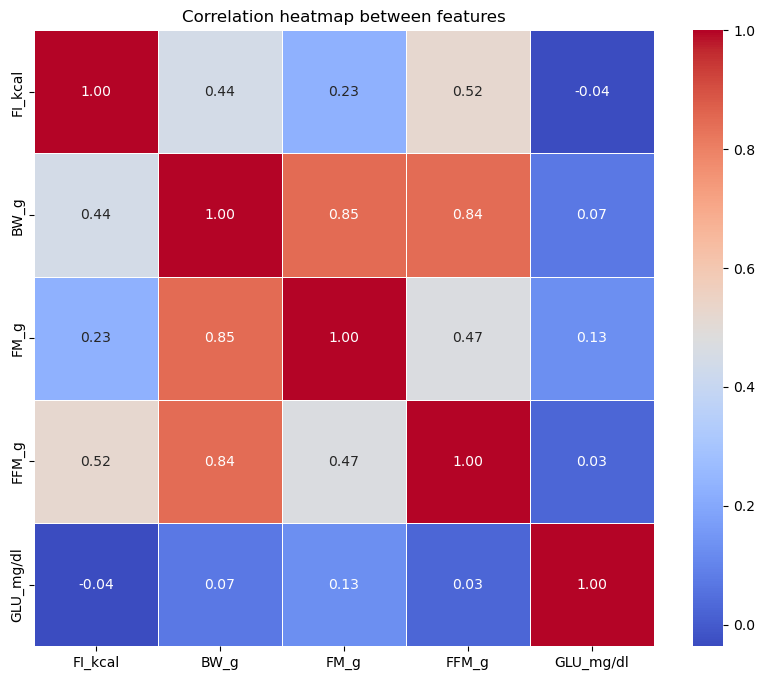

In [4]:
#time-dependent features correlation in dataset F_1

columns_drop = [ 'ID',
    'aggression_index',
    'CD1', 
    'C57BL6J',   
    'Sv129Ev',
    'rank',
    'time_point_in_study_weeks']
df_cor = X.drop(columns=columns_drop)
correlation_matrix=df_cor.corr()

#print("correlation matrix", correlation_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=.5)
plt.title('Correlation heatmap between features')
plt.show()

In [5]:
# Generate time point pairs for each ID
# Extract pairs where i < j (weeks)

id_time_point_pairs = []
for id_val in X['ID'].unique():
    time_points = sorted(X[X['ID'] == id_val]['time_point_in_study_weeks'].unique())
    for tp_i, tp_j in itertools.combinations(time_points, 2):
        id_time_point_pairs.append({'ID': id_val, 'time_point_i': tp_i, 'time_point_j': tp_j})

# Create DataFrame from time point pairs
pairs_df = pd.DataFrame(id_time_point_pairs)

print(pairs_df)
#print(pairs_df['time_point_j'].min(), pairs_df['time_point_j'].max())

        ID  time_point_i  time_point_j
0      282             0             4
1      282             0             8
2      282             0            12
3      282             0            20
4      282             0            28
...    ...           ...           ...
15434  738            20            36
15435  738            20            44
15436  738            28            36
15437  738            28            44
15438  738            36            44

[15439 rows x 3 columns]


In [6]:
# Expand time-dependent features to two time points (generating dynamic features)
features_to_merge = ['FI_kcal', 'BW_g', 'FM_g', 'FFM_g', 'GLU_mg/dl'] # time-dependent features
features_to_merge_other = ['aggression_index',  'CD1', 'C57BL6J', 'Sv129Ev', 'rank'] #time-independent features

# Merge data for time-point i
F_i_features = X[['ID', 'time_point_in_study_weeks'] + features_to_merge].copy()
i_columns_to_rename = {col: f"{col}_i" for col in features_to_merge}
#print(F_i_features)

merged_df = pd.merge(
    pairs_df,
    F_i_features.rename(columns=i_columns_to_rename).rename(columns={'time_point_in_study_weeks': 'time_point_i'}),
    on=['ID', 'time_point_i'],
    how='left'
)

# Merge data for time-point j
F_j_features = X[['ID', 'time_point_in_study_weeks'] + features_to_merge+ features_to_merge_other].copy()
j_columns_to_rename = {col: f"{col}_j" for col in features_to_merge}
#print(F_j_features)

merged_df = pd.merge(
    merged_df,
    F_j_features.rename(columns=j_columns_to_rename).rename(columns={'time_point_in_study_weeks': 'time_point_j'}),
    on=['ID', 'time_point_j'],
    how='left'
)
#print(merged_df)


#concatenate(Fc)
F_con = pd.concat([merged_df[['FI_kcal_i', 'BW_g_i', 'FM_g_i', 'FFM_g_i', 'GLU_mg/dl_i']].copy(),merged_df[['FI_kcal_j', 'BW_g_j', 'FM_g_j', 'FFM_g_j', 'GLU_mg/dl_j']].copy()],axis=1)

#difference(Fd) and rate of change(Fr)
F_i_timepoint_phenotype = merged_df[['FI_kcal_i', 'BW_g_i', 'FM_g_i', 'FFM_g_i', 'GLU_mg/dl_i','time_point_i']].copy()
F_j_timepoint_phenotype = merged_df[['FI_kcal_j', 'BW_g_j', 'FM_g_j', 'FFM_g_j', 'GLU_mg/dl_j','time_point_j']].copy()

#difference(Fd)
F_i_dif = F_i_timepoint_phenotype.rename(columns={
    'FI_kcal_i': 'FI_kcal_dif',
    'BW_g_i': 'BW_g_dif',
    'FM_g_i': 'FM_g_dif',
    'FFM_g_i': 'FFM_g_dif',
    'GLU_mg/dl_i': 'GLU_mg/dl_dif',
    'time_point_i': 'time_point_dif'
})
F_j_dif = F_j_timepoint_phenotype.rename(columns={
    'FI_kcal_j': 'FI_kcal_dif',
    'BW_g_j': 'BW_g_dif',
    'FM_g_j': 'FM_g_dif',
    'FFM_g_j': 'FFM_g_dif',
    'GLU_mg/dl_j': 'GLU_mg/dl_dif',
    'time_point_j': 'time_point_dif'
})
F_dif_i_j = F_j_dif - F_i_dif
F_dif = F_dif_i_j.drop(columns=['time_point_dif'])

#rate of change(Fr)
F_i_rat = F_i_timepoint_phenotype.rename(columns={
    'FI_kcal_i': 'FI_kcal_rat',
    'BW_g_i': 'BW_g_rat',
    'FM_g_i': 'FM_g_rat',
    'FFM_g_i': 'FFM_g_rat',
    'GLU_mg/dl_i': 'GLU_mg/dl_rat',
    'time_point_i': 'time_point_rat'
})
F_j_rat = F_j_timepoint_phenotype.rename(columns={
    'FI_kcal_j': 'FI_kcal_rat',
    'BW_g_j': 'BW_g_rat',
    'FM_g_j': 'FM_g_rat',
    'FFM_g_j': 'FFM_g_rat',
    'GLU_mg/dl_j': 'GLU_mg/dl_rat',
    'time_point_j': 'time_point_rat'
})
F_rat_i_j = F_j_rat - F_i_rat
F_rat = F_rat_i_j[['FI_kcal_rat', 'BW_g_rat', 'FM_g_rat', 'FFM_g_rat', 'GLU_mg/dl_rat']].div(F_rat_i_j['time_point_rat'],axis=0)

#time-point(Ft)
F_time = pd.concat([merged_df['time_point_i'],merged_df['time_point_j']],axis=1)

#static feature(Fs)
F_sta = merged_df[['ID'] + features_to_merge_other].copy()

print('\nFc',F_con)
print('\nFd',F_dif)
print('\nFr',F_rat)
print('\nFt',F_time)
print('\nFs',F_sta)


Fc        FI_kcal_i  BW_g_i  FM_g_i  FFM_g_i  GLU_mg/dl_i  FI_kcal_j  BW_g_j  \
0         18.480    45.0   10.22    32.76        163.0     14.630    41.7   
1         18.480    45.0   10.22    32.76        163.0     20.790    63.8   
2         18.480    45.0   10.22    32.76        163.0     10.780    68.2   
3         18.480    45.0   10.22    32.76        163.0     19.635    68.7   
4         18.480    45.0   10.22    32.76        163.0     21.945    70.8   
...          ...     ...     ...      ...          ...        ...     ...   
15434     13.860    43.2   13.25    27.58        165.0     12.320    48.1   
15435     13.860    43.2   13.25    27.58        165.0      5.390    38.0   
15436     13.475    45.1   14.37    28.80        160.0     12.320    48.1   
15437     13.475    45.1   14.37    28.80        160.0      5.390    38.0   
15438     12.320    48.1   15.83    30.19        119.0      5.390    38.0   

       FM_g_j  FFM_g_j  GLU_mg/dl_j  
0        6.49    33.60        137

In [8]:
# dataset selection

# 0: Fc + Ft + Fs
# 1: Fd + Ft + Fs
# 2: Fr + Ft + Fs
# 3: Fc + Fd + Ft + Fs
# 4: Fc + Fr + Ft + Fs
# 5: Fd + Fr + Ft + Fs
# 6: Fc + Fd + Fr + Ft + Fs
# 7: F_1

#ablation dataset is only 6
dataset_num = 6

F_c_t_s = pd.concat([F_con,F_time,F_sta],axis=1)
F_d_t_s = pd.concat([F_dif,F_time,F_sta],axis=1)
F_r_t_s = pd.concat([F_rat,F_time,F_sta],axis=1)
F_c_d_t_s = pd.concat([F_con,F_dif,F_time,F_sta],axis=1)
F_c_r_t_s = pd.concat([F_con,F_rat,F_time,F_sta],axis=1)
F_d_r_t_s = pd.concat([F_dif,F_rat,F_time,F_sta],axis=1)
F_c_d_r_t_s = pd.concat([F_con,F_dif,F_rat,F_time,F_sta],axis=1)

if dataset_num == 0:
    dataset=F_c_t_s
    dataset_name = 'F_c_t_s'
elif dataset_num == 1:
    dataset=F_d_t_s
    dataset_name = 'F_d_t_s'
elif dataset_num == 2:
    dataset=F_r_t_s
    dataset_name = 'F_r_t_s'
elif dataset_num == 3:
    dataset=F_c_d_t_s
    dataset_name = 'F_c_d_t_s'
elif dataset_num == 4:
    dataset=F_c_r_t_s
    dataset_name = 'F_c_r_t_s'
elif dataset_num == 5:
    dataset=F_d_r_t_s
    dataset_name = 'F_d_r_t_s'
elif dataset_num == 6:
    dataset=F_c_d_r_t_s
    dataset_name = 'F_c_d_r_t_s'
else:
    dataset=F_1
    dataset_name = 'F_1'
    loss_bins = None
    eva_bins = 15
    
print(dataset_name)

dataset

F_c_d_r_t_s


,FI_kcal_i,BW_g_i,FM_g_i,FFM_g_i,GLU_mg/dl_i,FI_kcal_j,BW_g_j,FM_g_j,FFM_g_j,GLU_mg/dl_j,...,FFM_g_rat,GLU_mg/dl_rat,time_point_i,time_point_j,ID,aggression_index,CD1,C57BL6J,Sv129Ev,rank
0,18.480,45.0,10.22,32.76,163.0,14.630,41.7,6.49,33.60,137.0,...,0.210000,-6.500000,0,4,282,1.070400,1,0,0,2
1,18.480,45.0,10.22,32.76,163.0,20.790,63.8,21.47,40.08,150.0,...,0.915000,-1.625000,0,8,282,1.070400,1,0,0,2
2,18.480,45.0,10.22,32.76,163.0,10.780,68.2,23.70,41.23,234.0,...,0.705833,5.916667,0,12,282,1.070400,1,0,0,2
3,18.480,45.0,10.22,32.76,163.0,19.635,68.7,23.31,42.91,330.0,...,0.507500,8.350000,0,20,282,1.070400,1,0,0,2
4,18.480,45.0,10.22,32.76,163.0,21.945,70.8,23.85,43.63,326.0,...,0.388214,5.821429,0,28,282,1.070400,1,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15434,13.860,43.2,13.25,27.58,165.0,12.320,48.1,15.83,30.19,119.0,...,0.163125,-2.875000,20,36,738,0.712097,0,1,0,2
15435,13.860,43.2,13.25,27.58,165.0,5.390,38.0,6.65,29.33,103.0,...,0.072917,-2.583333,20,44,738,0.712097,0,1,0,2
15436,13.475,45.1,14.37,28.80,160.0,12.320,48.1,15.83,30.19,119.0,...,0.173750,-5.125000,28,36,738,0.712097,0,1,0,2
15437,13.475,45.1,14.37,28.80,160.0,5.390,38.0,6.65,29.33,103.0,...,0.033125,-3.562500,28,44,738,0.712097,0,1,0,2


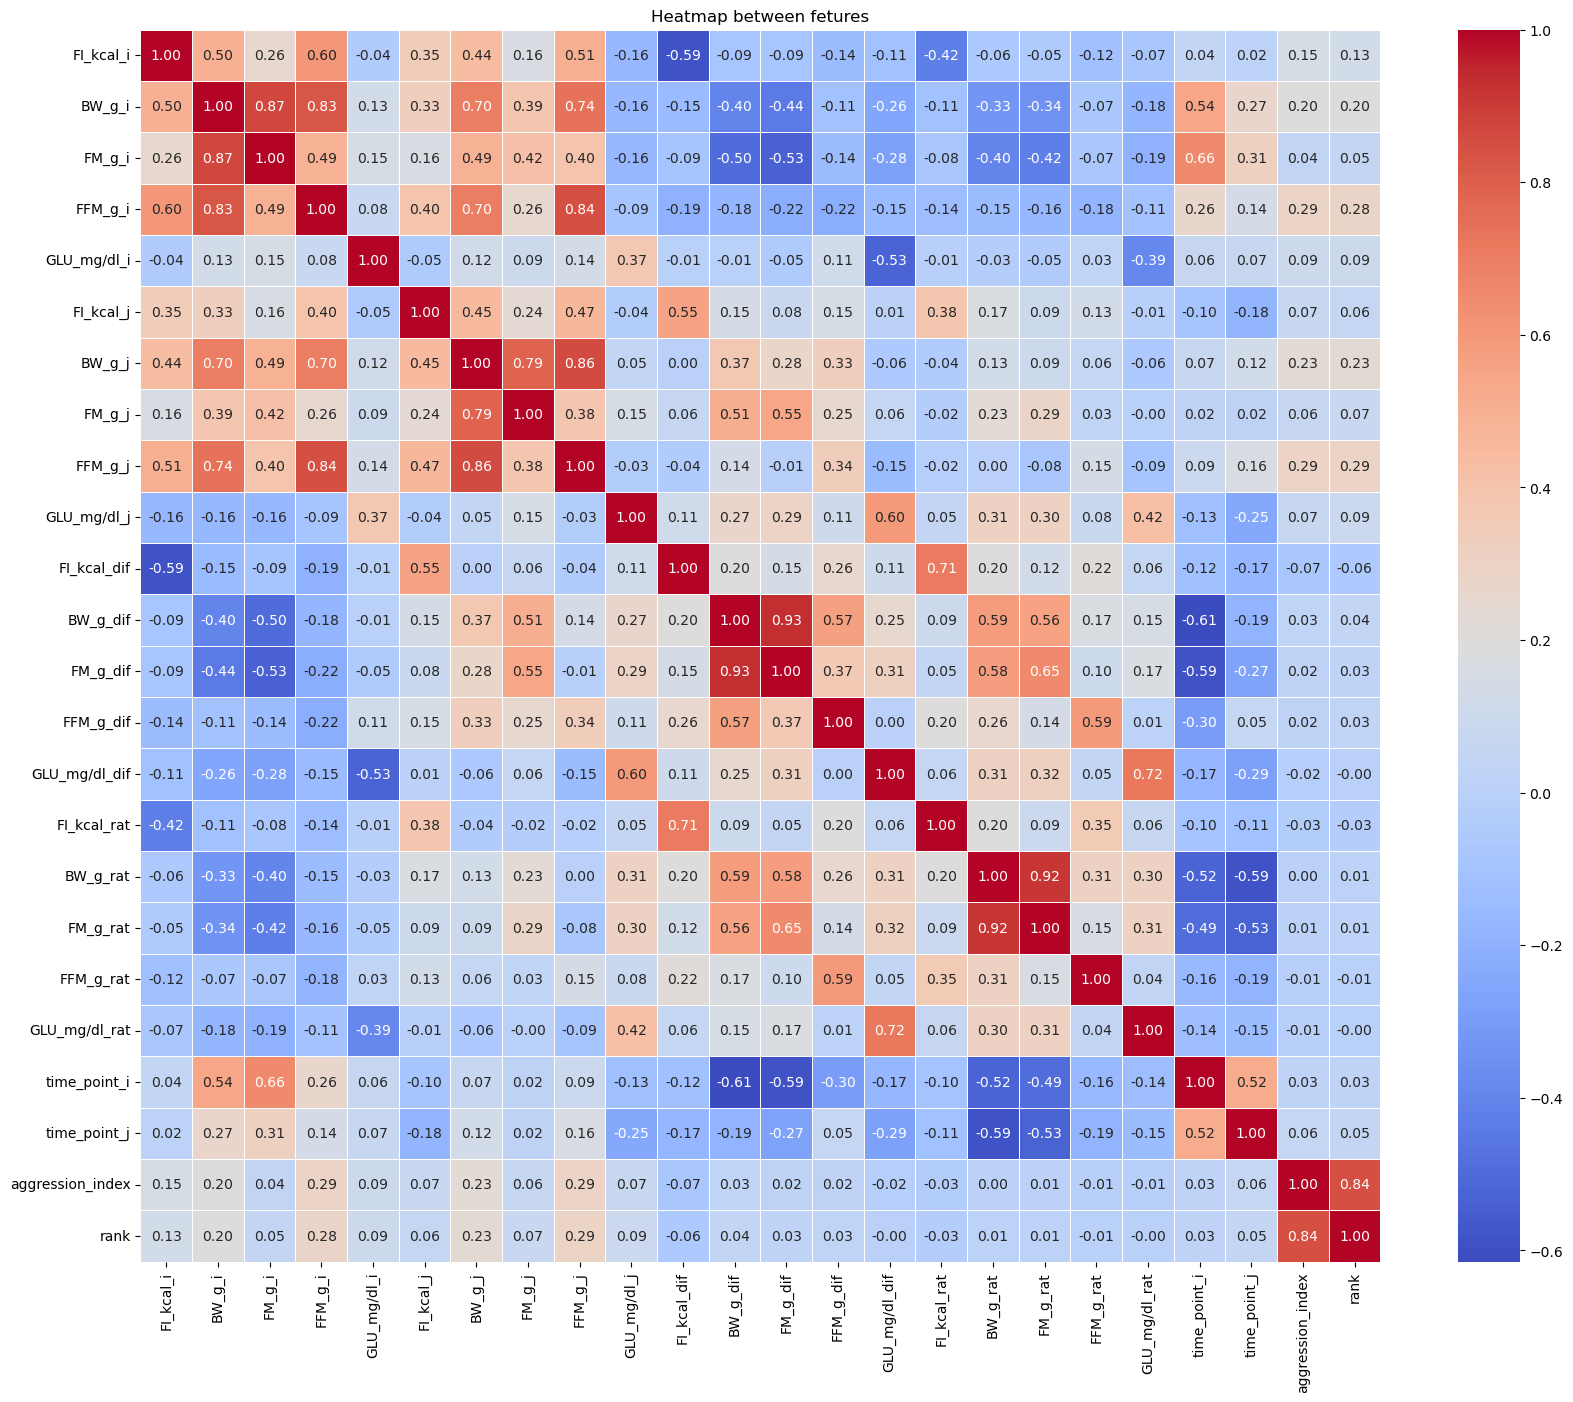

In [9]:
#features correlation in dataset
cor_col = [c for c in dataset.columns if not set(dataset[c].unique()).issubset({0,1})]
correlation_matrix=dataset[cor_col].drop(columns=['ID']).corr()

plt.figure(figsize=(20,16))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=.5)
plt.title('Heatmap between fetures')
plt.show()

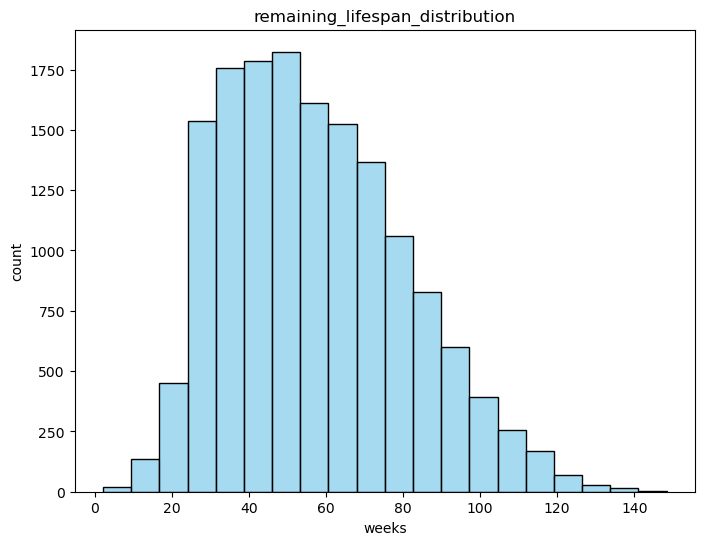

Max: 148.38899999999998, Min: 2.1809999999999974


0        65.399
1        61.399
2        57.399
3        49.399
4        41.399
          ...  
15434    23.079
15435    15.079
15436    23.079
15437    15.079
15438    15.079
Name: remaining_lifespan_from_j, Length: 15439, dtype: float64

In [10]:
#remaining lifespan distribution

loss_bins=None #None
eva_bins = 15 #do not change this value basically

if dataset_name != 'F_1':
    # Prepare the target data for time_point_j
    y_source_data_for_j = (
        data[['ID', 'time_point_in_study_weeks', 'remaining_lifespan']]
        .rename(columns={
            'time_point_in_study_weeks': 'time_point_j',
            'remaining_lifespan': 'remaining_lifespan_from_j'
        })
    )

    # Merge remaining_lifespan_from_j into merged_df by ID and time_point_j
    merged_df = merged_df.merge(
        y_source_data_for_j,
        on=['ID', 'time_point_j'],
        how='left'
    )

    # Extract target aligned with merged_df rows
    y = merged_df['remaining_lifespan_from_j']
else:
    y = data['remaining_lifespan']
plt.figure(figsize=(8,6))
sns.histplot(y, kde=False, bins = 20, color='skyblue')
plt.title('remaining_lifespan_distribution')
plt.xlabel('weeks')
plt.ylabel('count')
plt.show()

print(f"Max: {max(y)}, Min: {min(y)}")
y

In [ ]:
#experiment 3.1/3.2 Individual-wise strain-stratified cross-validation (CV)

batch_size = 32
n_iterations = 20 #fold
pred_mode = "NN" #GB,SVR or NN
groups=dataset['ID']
loss_mode="MAE" #MAE or RMSE 
test_error_mode="MAE" #MAE or RMSE
patience = 10 #early stopping

test_predictions, each_fold_rmse,each_fold_mae,each_fold_SLMAE, each_fold_SLMAE_std,each_fold_SLRMSE, each_fold_strain_mae = cross_validation(dataset, y, loss_bins, eva_bins, groups, batch_size, n_iterations,loss_mode,test_error_mode,patience,pred_mode)

print("finished cross validation")

In [ ]:
#results 
#average fold error
average_SLMAE= np.mean(each_fold_SLMAE)
average_SLMAE_std= np.mean(each_fold_SLMAE_std)
average_SLRMSE= np.mean(each_fold_SLRMSE)
average_rmse = np.mean(each_fold_rmse)
average_mae = np.mean(each_fold_mae)

df_strain_mae = pd.DataFrame(each_fold_strain_mae)

#strandard deviation of fold error
std_SLMAE=np.std(each_fold_SLMAE,ddof=1)
std_SLMAE_std=np.std(each_fold_SLMAE_std,ddof=1)
std_SLRMSE=np.std(each_fold_SLRMSE,ddof=1)
std_rmse=np.std(each_fold_rmse,ddof=1)
std_mae=np.std(each_fold_mae,ddof=1)

strain_means = df_strain_mae.mean()
strain_errors = df_strain_mae.std(ddof=1) / np.sqrt(len(df_strain_mae))

#standard error (standard deviation of error/√fold)
std_SLMAE_error=std_SLMAE/np.sqrt(len(each_fold_SLMAE))
std_SLMAE_std_error=std_SLMAE_std/np.sqrt(len(each_fold_SLMAE_std))
std_SLRMSE_error=std_SLRMSE/np.sqrt(len(each_fold_SLRMSE))
std_rmse_error=std_rmse/np.sqrt(len(each_fold_rmse))
std_mae_error=std_mae/np.sqrt(len(each_fold_mae))

df_rmse = pd.DataFrame(each_fold_rmse, columns=['RMSE'])
df_mae = pd.DataFrame(each_fold_mae, columns=['MAE'])
df_SLMAE = pd.DataFrame(each_fold_SLMAE, columns=['SLMAE'])
df_SLMAE_std = pd.DataFrame(each_fold_SLMAE_std, columns=['SLMAE_std'])
df_SLRMSE = pd.DataFrame(each_fold_SLRMSE, columns=['SLRMSE'])

stats_df = pd.DataFrame({
    'Metric': ['Average RMSE', 'Average MAE', 'Average SLMAE','Average SLMAE_std', 'Average SLRMSE', 'Standard Error RMSE', 'Standard Error MAE', 'Standard Error SLMAE', 'Standard Error SLMAE_std', 'Standard Error SLRMSE'],
    'Value': [average_rmse, average_mae, average_SLMAE, average_SLMAE_std, average_SLRMSE,std_rmse_error, std_mae_error, std_SLMAE_error, std_SLMAE_std_error,std_SLRMSE_error]
})

new_metrics = []
new_values =[]
for s_name in strain_means.index:
    new_metrics.append(f'Average MAE {s_name}')
    new_values.append(strain_means[s_name])
    new_metrics.append(f'Standard Error MAE {s_name}')
    new_values.append(strain_errors[s_name])

new_stats = pd.DataFrame({'Metric': new_metrics, 'Value': new_values})
stats_df = pd.concat([stats_df, new_stats], ignore_index=True)

output_file = f"tj-wise_performance_'{pred_mode}'_'{dataset_name}'_'{loss_bins}'_{loss_mode}'.xlsx"
    
"""with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_rmse.to_excel(writer, sheet_name='Test Error', index=False)
    df_mae.to_excel(writer, sheet_name='Test Error', startcol = 1, index=False)
    df_SLMAE.to_excel(writer, sheet_name='Test Error', startcol = 2, index=False)
    df_SLMAE_std.to_excel(writer, sheet_name='Test Error', startcol = 3, index=False)
    df_SLRMSE.to_excel(writer, sheet_name='Test Error', startcol = 4, index=False)
    df_strain_mae.to_excel(writer, sheet_name= 'Test Error', startcol=5, index=False)
    stats_df.to_excel(writer, sheet_name='Summary_Statistics', index=False)"""

print(f'\nEach fold MAE: {each_fold_mae}')
print(f'\nEach fold SLMAE: {each_fold_SLMAE}')
print(f'\nAverage MAE: {average_mae}')
print(f'\nAverage SLMAE: {average_SLMAE}')
print(f'\nStandard deviation of fold errors: {std_mae}')
print(f'\nStandard deviation of SLMAE: {average_SLMAE_std}')
print(f'\nStrain-wise average MAE: {strain_means}')
#print(f'\nStandard error: {standard_error}')

print(f"Data saved to '{output_file}'.")

In [ ]:
# get formatted Loss
rmse_clipped = '{0:.3f}'.format(average_rmse)
mae_clipped = '{0:.3f}'.format(average_mae)
rmse_se_clipped = '{0:.3f}'.format(std_rmse_error)
mae_se_clipped = '{0:.3f}'.format(std_mae_error)
if average_SLMAE != 0:
    SLMAE_clipped = '{0:.3f}'.format(average_SLMAE)
    SLMAE_se_clipped = '{0:.3f}'.format(std_SLMAE_error)


if dataset_num != 7 and 'time_point_j' in test_predictions.columns:
    #For dual time-point datasets, average the predictions over i for each j
    plot_data = test_predictions.groupby(['ID','time_point_j'])[['actual', 'approximation']].mean().reset_index()
    print('average the predictions over t_i for each t_j')
else:
    plot_data = test_predictions

fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(7, 7))

plot_color_condition = None

if plot_data.empty:
    print("Warning: No data points to plot after filtering.")
    scatter = None
else:
    #2D Kernel Density Estimation (KDE)
    sns.kdeplot(
        data=plot_data,
        x='actual',
        y='approximation',
        ax=axs,
        fill=False,
        cmap="Reds_r",
        levels=6,
        alpha=0.6,
    )
    
    #scatter plot of predicted vs. actual remaining lifespan
    scatter = axs.scatter(
        x=plot_data['actual'],
        y=plot_data['approximation'],
        color = 'blue',
        alpha=0.1,
        s=4
    )

axs.set_aspect('equal', adjustable='box')

x_max = 170
axs.set_xlim([0,x_max])
axs.set_ylim([0,x_max])
axs.xaxis.set_major_locator(MultipleLocator(25))
axs.yaxis.set_major_locator(MultipleLocator(25))

# y=x (predicted = actual) line
y_x_line, =axs.plot([0, x_max], [0, x_max], color='gray', linestyle='--', label='y=x (Ideal Prediction)')

axs.grid(True, linestyle='--', alpha=0.6)

# Dummy plot for KDE legend display purposes
dummy_kde_line, = axs.plot([], [], color='darkred', linestyle='-', label='2D Kernel Density Estimate')

# legend
handles = [y_x_line, dummy_kde_line]
labels = [y_x_line.get_label(), dummy_kde_line.get_label()]
axs.legend(handles=handles, labels=labels, loc='upper left')

axs.set_xlim([0,x_max])
axs.set_ylim([0,x_max])

#axs.set_title('actual vs predicted', size=12)
axs.set_xlabel('Actual remaining lifespan (weeks)')
axs.set_ylabel('Predicted remaining lifespan (weeks)')


plt.tight_layout()
#plt.savefig("/mnt/c/Users/Kawakami/Desktop/result/result.jpeg", dpi=300)
plt.show()

print("RMSE:",rmse_clipped,"±",rmse_se_clipped)
print("MAE:",mae_clipped,"±",mae_se_clipped)
if average_SLMAE != 0:
    print("SLMAE:",SLMAE_clipped,"±",SLMAE_se_clipped)

In [12]:
#experiment 3.3 ablation save excel
def ablation_save_excel(results, filename = "ablation_results.xlsx"):
    writer = pd.ExcelWriter(filename, engine='xlsxwriter')
    workbook = writer.book
    worksheet = workbook.add_worksheet('Summary')

    header_fmt = workbook.add_format({'bold':True, 'align': 'center', 'valign': 'vcenter', 'border': 1, 'bg_color': '#D3D3D3'})
    cell_fmt = workbook.add_format({'border': 1, 'align': 'center'})

    current_col = 2
    for _, row in results.iterrows():
        feature = row['feature']
        mae_s = row['mae_single']
        mae_l = row['mae_leave_one_feature_out']

        worksheet.merge_range(0, current_col, 0, current_col+1, feature, header_fmt)
        worksheet.write(1, current_col, 'mae_single', header_fmt)
        worksheet.write(1, current_col+1, 'mae_leave', header_fmt)

        # write MAE values for each fold
        for i, (s, l) in enumerate(zip(mae_s, mae_l)):
            if  current_col == 2:
                worksheet.write(i+2, 1, f'fold_{i+1}_mae', cell_fmt)
            worksheet.write(i+2, current_col, s, cell_fmt)
            worksheet.write(i+2, current_col+1, l, cell_fmt)
        current_col += 2

    start_row = len(results.iloc[0]['mae_single']) + 5
    worksheet.write(start_row-1, 3, 'average_MAE', header_fmt)
    worksheet.write(start_row-1, 4, 'standard_deviation', header_fmt)

    for i, (_, row) in enumerate(results.iterrows()):
        r = start_row+(i*2)
        worksheet.merge_range(r, 1, r+1, 1, row['feature'], cell_fmt)

        worksheet.write(r, 2, 'mae_single', cell_fmt)
        worksheet.write(r, 3, np.mean(row['mae_single']), cell_fmt)
        worksheet.write(r, 4, np.std(row['mae_single']), cell_fmt)

        worksheet.write(r+1, 2, 'mae_leave', cell_fmt)
        worksheet.write(r+1, 3, np.mean(row['mae_leave_one_feature_out']), cell_fmt)
        worksheet.write(r+1, 4, np.std(row['mae_leave_one_feature_out']), cell_fmt)

    writer.close()
    print(f"Excel file '{filename}' has been created.")

In [13]:
# experiment 3.3 ablation study: leave-one-feature-out and single-feature analysis
def ablation(X, y, group_dict, base_params):
    results = []
    all_features = list(group_dict.keys())
    time_point_col = [col for col in X.columns if 'time_point' in col]
    strain_col = ['CD1', 'C57BL6J', 'Sv129Ev']
    essen_col = list(set(time_point_col + strain_col))

    tp_j_w = 1 #0:without t_j, 1:with t_j

    for feature in all_features:
        print(f"\n testing feature:{feature}")

        #single-feature-analysis
        print("""predicting from single feature""")
        feature_col = group_dict[feature]
        current_col = list(feature_col)+['ID']
        add_col = [c for c in essen_col if c not in current_col]
        X_single = X[current_col + add_col]

        if tp_j_w == 0:
            add_col = [c for c in add_col if c != "time_point_j"]

        if tp_j_w ==0 and feature == "time_point_j":
            print('skip')
        else:
            _, _, each_fold_mae_single, _, _, _, _ = cross_validation(X_single, y, ablation_drop_col = add_col, **base_params) 
            avg_mae_single = np.mean(each_fold_mae_single)

        #leave-one-feature-out analysis
        print("""predicting by removing single feature""")
        col_drop = [c for c in feature_col if c not in essen_col]
        if len(col_drop) == 0:
            if tp_j_w == 0:
                ablation_drop_col = feature_col+group_dict["time_point_j"]
            else:
                ablation_drop_col = feature_col
        else:
            if tp_j_w == 0:
                ablation_drop_col = group_dict["time_point_j"]
            else:
                ablation_drop_col = None
        X_minus = X.drop(columns=col_drop)

        if tp_j_w ==0 and feature == "time_point_j":
            print('skip')
        else:
            _, _, each_fold_mae_minus, _, _, _, _ = cross_validation(X_minus, y, ablation_drop_col = ablation_drop_col, **base_params)
            avg_mae_minus = np.mean(each_fold_mae_minus)

            result = ({
                'feature': feature,
                'mae_single': each_fold_mae_single,
                'mae_leave_one_feature_out':each_fold_mae_minus
            })
            results.append(result)
    return pd.DataFrame(results)

In [14]:
#define feature groups for ablation study
strain_cols = ['CD1', 'C57BL6J', 'Sv129Ev']
groups=dataset['ID']
feature_groups = {}

base_feature = ['FI_kcal', 'BW_g', 'FM_g', 'FFM_g', 'GLU_mg/dl']
exclude_keywords = ['_dif', '_rat']
feature_groups['Strain'] = [c for c in dataset.columns if c in strain_cols]

for base in base_feature:
    feature_groups[base] = [c for c in dataset.columns if c.startswith(base) and not any(kw in c for kw in exclude_keywords)]

all_grouped_cols = set()
for cols_in_group in feature_groups.values():
    all_grouped_cols.update(cols_in_group)

for col in dataset.columns:
    if col != 'ID' and col not in strain_cols and col not in all_grouped_cols:
        feature_groups[col] = [col]
        
base_params = {
    'loss_bins': loss_bins,
    'eva_bins':eva_bins,
    'groups': groups,
    'batch_size':32,
    'n_iterations':20,
    'loss_mode':'MAE',
    'test_error_mode':'MAE',
    'patience':30,
    'pred_mode': 'NN'
}
        
results = ablation(dataset, y, feature_groups, base_params)
#ablation_save_excel(results)


 testing feature:Strain
predicting from single feature
--- Fold 1/20---
Input X columns : ['CD1', 'C57BL6J', 'Sv129Ev']
Input X shape : 3
Early stopping at epoch 46
--- Fold 2/20---
Input X columns : ['CD1', 'C57BL6J', 'Sv129Ev']
Input X shape : 3
Early stopping at epoch 50
--- Fold 3/20---
Input X columns : ['CD1', 'C57BL6J', 'Sv129Ev']
Input X shape : 3
Early stopping at epoch 37
--- Fold 4/20---
Input X columns : ['CD1', 'C57BL6J', 'Sv129Ev']
Input X shape : 3
Early stopping at epoch 32
--- Fold 5/20---
Input X columns : ['CD1', 'C57BL6J', 'Sv129Ev']
Input X shape : 3
Early stopping at epoch 32
--- Fold 6/20---
Input X columns : ['CD1', 'C57BL6J', 'Sv129Ev']
Input X shape : 3
Early stopping at epoch 43
--- Fold 7/20---
Input X columns : ['CD1', 'C57BL6J', 'Sv129Ev']
Input X shape : 3
Early stopping at epoch 65
--- Fold 8/20---
Input X columns : ['CD1', 'C57BL6J', 'Sv129Ev']
Input X shape : 3
Early stopping at epoch 33
--- Fold 9/20---
Input X columns : ['CD1', 'C57BL6J', 'Sv129Ev']

In [ ]:
#Dataset derived from F_1 by excluding only "time_point_in_study_weeks"
groups=dataset['ID']
base_params = {
    'loss_bins': loss_bins,
    'eva_bins':eva_bins,
    'groups': groups,
    'batch_size':32,
    'n_iterations':20,
    'loss_mode':'MAE',
    'test_error_mode':'MAE',
    'patience':30,
    'pred_mode': 'NN'
}
test_predictions, each_fold_rmse,each_fold_mae,each_fold_SLMAE, each_fold_SLMAE_std,each_fold_SLRMSE, each_fold_strain_mae = cross_validation(dataset, y, ablation_drop_col = "time_point_in_study_weeks", **base_params) 

average_mae = np.mean(each_fold_mae)
print(f'\nAverage MAE: {average_mae}')

In [ ]:
#leave-one-strain-out CV
batch_size = 32
epochs=1000
repeat_num=10
print(dataset_name)
results = []

for i in range(repeat_num):
    mae,rmse,SLMAE, SLRMSE, SLMAE_std = loso(dataset, y, batch_size)
    results.append(mae)
results = np.array(results)
print(results)

In [ ]:
#single strain only CV save excel
def single_strain_save_excel(results, filename = "single_strain_results.xlsx"):
    writer = pd.ExcelWriter(filename, engine='xlsxwriter')
    workbook = writer.book
    worksheet = workbook.add_worksheet('Summary')

    header_fmt = workbook.add_format({'bold':True, 'align': 'center', 'valign': 'vcenter', 'border': 1, 'bg_color': '#D3D3D3'})
    cell_fmt = workbook.add_format({'border': 1, 'align': 'center'})

    current_col = 2
    for _, row in results.iterrows():
        strain = row['strain']
        mae_s = row['mae_single_strain']

        worksheet.write(0, current_col, strain, header_fmt)
        worksheet.write(1, current_col, 'mae_single_strain', header_fmt)

        # write MAE values for each fold
        for i, val in enumerate(mae_s):
            if  current_col == 2:
                worksheet.write(i+2, 1, f'fold_{i+1}_mae', cell_fmt)
            worksheet.write(i+2, current_col, val, cell_fmt)
        current_col += 1

    start_row = len(results.iloc[0]['mae_single_strain']) + 5
    worksheet.write(start_row-1, 3, 'average_MAE', header_fmt)
    worksheet.write(start_row-1, 4, 'standard_deviation', header_fmt)

    for i, (_, row) in enumerate(results.iterrows()):
        r = start_row+i
        worksheet.write(r, 1, row['strain'], cell_fmt)
        worksheet.write(r, 2, np.mean(row['mae_single_strain']), cell_fmt)
        worksheet.write(r, 3, np.std(row['mae_single_strain']), cell_fmt)

    writer.close()
    print(f"Excel file '{filename}' has been created.")

In [ ]:
#single strain only CV
groups=dataset['ID']
ids_CD1 = dataset[dataset['CD1']==1]['ID'].unique()
ids_Sv129 = dataset[dataset['Sv129Ev']==1]['ID'].unique()
ids_C57 = dataset[dataset['C57BL6J']==1]['ID'].unique()
len_strain_list = [len(ids_CD1), len(ids_Sv129), len(ids_C57)]
min_strain = min(len_strain_list)

np.random.seed(42)
selected_ids_CD1 = np.random.choice(ids_CD1, size = min_strain, replace=False)
selected_ids_Sv129 = np.random.choice(ids_Sv129, size = min_strain, replace=False)
selected_ids_C57 = np.random.choice(ids_C57, size = min_strain, replace=False)


X_CD1 = dataset[dataset['ID'].isin(selected_ids_CD1)].copy()
y_CD1 = y.loc[X_CD1.index].copy()
X_Sv129 = dataset[dataset['ID'].isin(selected_ids_Sv129)].copy()
y_Sv129 = y.loc[X_Sv129.index].copy()
X_C57 = dataset[dataset['ID'].isin(selected_ids_C57)].copy()
y_C57 = y.loc[X_C57.index].copy()

base_params = {
    'loss_bins': loss_bins,
    'eva_bins':eva_bins,
    'groups': groups,
    'batch_size':32,
    'n_iterations':20,
    'loss_mode':'MAE',
    'test_error_mode':'MAE',
    'patience':30,
    'pred_mode': 'NN'
}

strain_sets = [
    ("CD1", X_CD1, y_CD1),
    ("Sv129Ev", X_Sv129, y_Sv129),
    ("C57BL6J", X_C57, y_C57)
]

all_results = []
for name, X_strain, y_strain in strain_sets:
    print(f"\n cross-validation for: {name}")

    _, _, each_fold_mae, _, _, _, _ = cross_validation(X_strain, y_strain, **base_params)

    result = ({
            'strain': name,
            'mae_single_strain': each_fold_mae,
        })
    all_results.append(result)

results_df = pd.DataFrame(all_results)
single_strain_save_excel(results_df)